#### 연습 문제

1. 5월 19일 날짜에 작업했던 하이닉스 주식 데이터를 로드하는 방법을 이용
    - 야후파이낸스에서 일별 데이터를 로드하는 기간은 2000년부터 가능

2. opendartreader 라이브러리를 이용해서 영업이익 데이터를 로드
    - env 활용해서 api_key 데이터 공유 금지
    - Dart 전자공시 2015년부터 필수화
    - 2015년 이전의 데이터들은 웹크롤링을 이용하여 노가다해야함

3. 15년부터의 주가, 영업이익 데이터 로드하여 결합

4. 이동평균선(20일)을 생성하고 이격도 컬럼을 생성

5. 종가, 거래량, 이격도, 영업이익 데이터를 이용하여 LSTM 모델에 학습 데이터로 이용

6. train, test 비율을 85:15로 생성하여 데이터 예측 모델을 생성

7. 기본값  
`epoch` = 20  
`window` = 60  
`train_batch_size` = 32  
`test_batch_size` = 32  
`lr` = 0.001

In [164]:
import yfinance as yf
import pandas as pd
import numpy as np
import time

from opendartreader import OpenDartReader
from datetime import datetime
import os
from dotenv import load_dotenv

**1**

In [165]:
hynix = yf.Ticker('000660.KS')
df = hynix.history(period = '12y')
#df = hynix.history(start="2015-01-01")

In [166]:
df = df.reset_index()

In [167]:
df_2016 = df[df['Date'] >= '2015-12-31'].reset_index(drop=True)
# df = df.loc[df.index > '2015-01-01']

In [168]:
df_2016

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2016-01-04 00:00:00+09:00,2.693519e+04,2.711153e+04,2.658252e+04,2.658252e+04,1878039,0.0,0.0
1,2016-01-05 00:00:00+09:00,2.689111e+04,2.750828e+04,2.675886e+04,2.697928e+04,2482905,0.0,0.0
2,2016-01-06 00:00:00+09:00,2.697928e+04,2.724379e+04,2.671478e+04,2.711154e+04,2461593,0.0,0.0
3,2016-01-07 00:00:00+09:00,2.680294e+04,2.711153e+04,2.662661e+04,2.662661e+04,2424880,0.0,0.0
4,2016-01-08 00:00:00+09:00,2.627394e+04,2.653844e+04,2.605352e+04,2.618577e+04,3967121,0.0,0.0
...,...,...,...,...,...,...,...,...
2539,2026-05-20 00:00:00+09:00,1.743000e+06,1.778000e+06,1.690000e+06,1.745000e+06,5535123,0.0,0.0
2540,2026-05-21 00:00:00+09:00,1.801000e+06,1.954000e+06,1.796000e+06,1.940000e+06,5096690,0.0,0.0
2541,2026-05-22 00:00:00+09:00,1.942000e+06,1.952000e+06,1.912000e+06,1.941000e+06,3135190,0.0,0.0
2542,2026-05-26 00:00:00+09:00,2.008000e+06,2.087000e+06,2.006000e+06,2.052000e+06,4903591,0.0,0.0


In [169]:
df_2016['MA20'] = df_2016['Close'].rolling(20).mean()
df_2016['Dist_MA20'] = (df_2016['Close']-df_2016['MA20']) / df_2016['MA20']

In [170]:
df_2016.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,MA20,Dist_MA20
0,2016-01-04 00:00:00+09:00,26935.193732,27111.528879,26582.523438,26582.523438,1878039,0.0,0.0,NaN,NaN
1,2016-01-05 00:00:00+09:00,26891.109771,27508.282782,26758.858411,26979.277344,2482905,0.0,0.0,NaN,NaN
2,2016-01-06 00:00:00+09:00,26979.283765,27243.786547,26714.780983,27111.535156,2461593,0.0,0.0,NaN,NaN
3,2016-01-07 00:00:00+09:00,26802.942570,27111.529080,26626.607422,26626.607422,2424880,0.0,0.0,NaN,NaN
4,2016-01-08 00:00:00+09:00,26273.939065,26538.441807,26053.520113,26185.771484,3967121,0.0,0.0,NaN,NaN


**2**

In [171]:
load_dotenv()

True

In [172]:
api_key = os.getenv('api_key')

In [173]:
dart = OpenDartReader(api_key)

In [174]:
years = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
# years = range(2015, 2027)

# current_year = datetime.now().year
# years = range(2015, current_year + 1)
# years
report_codes = ['11013', '11012', '11014', '11011']
dart_data_list = []

In [175]:
for year in years:
    for code in report_codes:
        try:
            report = dart.finstate('000660', year, code)
            if report is not None:
                op_profit = report[(report['fs_div'] == 'CFS') & (report['account_nm'] == '영업이익')]
                if not op_profit.empty:
                    val = int(op_profit['thstrm_amount'].values[0].replace(',', ''))
                    if code == '11013' : d = f"{year}-05-15"
                    elif code == '11012' : d = f"{year}-08-14"
                    elif code == '11014' : d = f"{year}-11-14"
                    else: d = f"{year+1}-03-31"
                    
                    report_date = pd.to_datetime(d)
                    if report_date <= datetime.now():
                        dart_data_list.append({'Date': report_date, 'Operation_Profit': val})
            time.sleep(1)

        except: continue

dart_data_list

{'status': '013', 'message': '조회된 데이타가 없습니다.'}

{'status': '013', 'message': '조회된 데이타가 없습니다.'}

{'status': '013', 'message': '조회된 데이타가 없습니다.'}

{'status': '013', 'message': '조회된 데이타가 없습니다.'}

{'status': '013', 'message': '조회된 데이타가 없습니다.'}

{'status': '013', 'message': '조회된 데이타가 없습니다.'}



[{'Date': Timestamp('2016-03-31 00:00:00'), 'Operation_Profit': 5336100000000},
 {'Date': Timestamp('2016-05-15 00:00:00'), 'Operation_Profit': 561798000000},
 {'Date': Timestamp('2016-08-14 00:00:00'), 'Operation_Profit': 452853000000},
 {'Date': Timestamp('2016-11-14 00:00:00'), 'Operation_Profit': 725956000000},
 {'Date': Timestamp('2017-03-31 00:00:00'), 'Operation_Profit': 3276746000000},
 {'Date': Timestamp('2017-05-15 00:00:00'), 'Operation_Profit': 2467599000000},
 {'Date': Timestamp('2017-08-14 00:00:00'), 'Operation_Profit': 3050700000000},
 {'Date': Timestamp('2017-11-14 00:00:00'), 'Operation_Profit': 3737193000000},
 {'Date': Timestamp('2018-03-31 00:00:00'),
  'Operation_Profit': 13721326000000},
 {'Date': Timestamp('2018-05-15 00:00:00'), 'Operation_Profit': 4367338000000},
 {'Date': Timestamp('2018-08-14 00:00:00'), 'Operation_Profit': 5573918000000},
 {'Date': Timestamp('2018-11-14 00:00:00'), 'Operation_Profit': 6472420000000},
 {'Date': Timestamp('2019-03-31 00:00:00

In [176]:
dart_df = pd.DataFrame(dart_data_list)

In [177]:
dart_df.head()

,Date,Operation_Profit
0,2016-03-31,5336100000000
1,2016-05-15,561798000000
2,2016-08-14,452853000000
3,2016-11-14,725956000000
4,2017-03-31,3276746000000


In [178]:
dart_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              42 non-null     datetime64[us]
 1   Operation_Profit  42 non-null     int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 804.0 bytes


In [179]:
df_2016['Date'] = df_2016['Date'].dt.date

In [180]:
df_2016['Date'] = pd.to_datetime(df_2016['Date'])

In [181]:
df_2016.info()

<class 'pandas.DataFrame'>
RangeIndex: 2544 entries, 0 to 2543
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype        
---  ------        --------------  -----        
 0   Date          2544 non-null   datetime64[s]
 1   Open          2544 non-null   float64      
 2   High          2544 non-null   float64      
 3   Low           2544 non-null   float64      
 4   Close         2544 non-null   float64      
 5   Volume        2544 non-null   int64        
 6   Dividends     2544 non-null   float64      
 7   Stock Splits  2544 non-null   float64      
 8   MA20          2525 non-null   float64      
 9   Dist_MA20     2525 non-null   float64      
dtypes: datetime64[s](1), float64(8), int64(1)
memory usage: 198.9 KB


In [182]:
df_2016.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,MA20,Dist_MA20
0,2016-01-04,26935.193732,27111.528879,26582.523438,26582.523438,1878039,0.0,0.0,NaN,NaN
1,2016-01-05,26891.109771,27508.282782,26758.858411,26979.277344,2482905,0.0,0.0,NaN,NaN
2,2016-01-06,26979.283765,27243.786547,26714.780983,27111.535156,2461593,0.0,0.0,NaN,NaN
3,2016-01-07,26802.942570,27111.529080,26626.607422,26626.607422,2424880,0.0,0.0,NaN,NaN
4,2016-01-08,26273.939065,26538.441807,26053.520113,26185.771484,3967121,0.0,0.0,NaN,NaN


**3**

In [183]:
df_2016['Date'] = df_2016['Date'].dt.date.astype('datetime64[s]')
dart_df['Date'] = dart_df['Date'].astype('datetime64[s]')

In [184]:
df_2016.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,MA20,Dist_MA20
0,2016-01-04,26935.193732,27111.528879,26582.523438,26582.523438,1878039,0.0,0.0,NaN,NaN
1,2016-01-05,26891.109771,27508.282782,26758.858411,26979.277344,2482905,0.0,0.0,NaN,NaN
2,2016-01-06,26979.283765,27243.786547,26714.780983,27111.535156,2461593,0.0,0.0,NaN,NaN
3,2016-01-07,26802.942570,27111.529080,26626.607422,26626.607422,2424880,0.0,0.0,NaN,NaN
4,2016-01-08,26273.939065,26538.441807,26053.520113,26185.771484,3967121,0.0,0.0,NaN,NaN


In [185]:
dart_df.head()

,Date,Operation_Profit
0,2016-03-31,5336100000000
1,2016-05-15,561798000000
2,2016-08-14,452853000000
3,2016-11-14,725956000000
4,2017-03-31,3276746000000


In [186]:
# display(df.head(1))
# display(dart_df.head(1))

# 시차를 제거해야 합칠 수 있다.
# df.index = df.index.tz_localize(None)

In [187]:
df1 = pd.merge_asof(df_2016, dart_df, on='Date', direction='backward')
# pd.merge_asof(df_2016, dart_df, left_index = True, right_on = 'Date', direction='backward')
df1.dropna(inplace=True)

**4**

In [188]:
df1.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,MA20,Dist_MA20,Operation_Profit
59,2016-03-31,25304.097511,25436.348891,24686.924401,24819.175781,4336581,0.0,0.0,26311.408789,-0.056714,5.336100e+12
60,2016-04-01,25083.678735,25127.762529,24731.008384,24863.259766,2991431,0.0,0.0,26148.298926,-0.049144,5.336100e+12
61,2016-04-04,24775.087093,24819.170877,24510.584383,24598.751953,2823088,0.0,0.0,25971.963672,-0.052873,5.336100e+12
62,2016-04-05,24598.749797,24775.084921,24334.247111,24554.666016,2032745,0.0,0.0,25855.141602,-0.050299,5.336100e+12
63,2016-04-06,24290.169730,24554.672486,24202.002145,24246.085938,2410844,0.0,0.0,25720.686230,-0.057331,5.336100e+12


**5**

In [189]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [190]:
# 하나의 함수화
# 매개변수로 사용할 데이터들은 어떤 것이 있을까?

# 파일의 경로를 지정하는 변수 (read_csv)
# file_path = '../csv/aapl.csv'

# 구간(window) 설정 (Dataset)
window = 60

# batch size 지정 (DataLoader)
x_batch = 32
y_batch = 32

# 기여도 (optimizer)
lr = 0.001

# 반복 학습 횟수
epochs = 20

# 은닉층에서의 뉴런(feature)의 개수
hidden_cnt = 64

# Layer 설정값
layer_cnt = 1

# train, test 비율
train_ratio = 0.85

# 은닉층, 셀 구조에서 어떤 부분을 사용할 것인가?
    # 'h': 은닉층 사용 // 'c': 셀 사용 // 'h_c': 둘 다 사용
head_type = 'h_c'

In [191]:
X = df1[['Volume', 'MA20', 'Dist_MA20']].astype(float).values
y = df1[['Close']].astype(float).values

**6**

In [192]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size = train_ratio, shuffle = False
)

In [193]:
class WindowDataset(Dataset):
    def __init__(self, _x, _y, _window):
        self.x = _x
        self.y = _y
        self.window = _window
        self.n = (len(_x) - _window)
    
    def __len__(self):
        return max(self.n, 1)
    
    def __getitem__(self, idx):
        x = self.x[idx  :  idx + self.window]
        y = self.y[idx + self.window]
        x_tensor = torch.tensor(x, dtype = torch.float32)
        y_tensor = torch.tensor(y, dtype = torch.float32)
        return x_tensor, y_tensor

In [194]:
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_sc = scaler_x.fit_transform(X_train)
X_test_sc = scaler_x.transform(X_test)
y_train_sc = scaler_y.fit_transform(y_train)
y_test_sc = scaler_y.transform(y_test)

In [195]:
train_ds = WindowDataset(X_train_sc, y_train_sc, window)
test_ds = WindowDataset(X_test_sc, y_test_sc, window)

In [196]:
train_dl = DataLoader(train_ds, shuffle = True, drop_last = True, batch_size = x_batch)
test_dl = DataLoader(test_ds, shuffle = False, drop_last=False, batch_size = y_batch)

In [197]:
# LSTM 모델의 정의

class LSTMModel(nn.Module):
    
    def __init__(
            self,
            input_size,
            hidden_size = 64,
            num_layers = 1,
            dropout = 0.0,
            bidirectional = False,
            batch_first = True,
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()

        # LSTM 기본 설정
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            dropout = dropout,
            bidirectional = bidirectional,
            batch_first = batch_first
        )

        # bidirectional이 True면 out feature의 개수가 2배
        hidden_size = hidden_size * (2 if bidirectional else 1)

        # head_type에 따라서 출력의 feature 개수가 달라진다.
        if head_type in ['h', 'c']:
        #if (head_type == 'h') | (head_type == 'c')
            pass
        elif head_type == 'h_c':
            hidden_size = hidden_size * 2
        else:
            print('head_type의 인자값을 잘못 입력하였습니다. ("h", "c", "h_c")를 사용해주세요')
        
        # 선형 모델 생성
        self.model = nn.Linear(hidden_size, 1)
            # 객체 안에 독립적인 데이터를 저장
        self.head_type = head_type

    # 순전파 함수 정의
    def forward(self, x):
        # 순전파의 예측값 (RNN은 2개를 되돌려줌, LSTM은 3개를 되돌려줌)
        out, (h_n, c_n) = self.lstm(x)
        # 은닉층의 가장 마지막값 저장
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
            feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last, c_last], dim = -1)
        
        return self.model(feat)

In [198]:
model = LSTMModel(input_size = 3, hidden_size = hidden_cnt, head_type = head_type)
model

LSTMModel(
  (lstm): LSTM(3, 64, batch_first=True)
  (model): Linear(in_features=128, out_features=1, bias=True)
)

In [199]:
# 손실 함수
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = lr)

In [200]:
# 검증 데이터의 loss값 확인하는 함수

# @torch.no_grad()
def evaluate_mse(dl):
    model.eval()

    total_loss, total_n = 0.0, 0
    # 데코레이터 또는 여기 사용
    with torch.no_grad():
        for x, y in dl:
            x = x.float()
            y = y.float()
            pred = model(x)
            loss = criterion(pred, y)
            total_loss += loss.item() * y.size(0)
            total_n += y.size(0)
    
    return total_loss / max(total_n, 1)

In [201]:
# 반복 학습

test_history = []

for epoch in range(epochs):
    model.train()

    total_loss, total_n = 0.0, 0
    
    for x, y in train_dl:
        x = x.float()
        y = y.float()

        pred = model(x)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        # 기울기 발산 방지 (이 자리 아니면 소용 없음)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)
    
    train_loss = total_loss / max(total_n, 1)
    test_loss = evaluate_mse(test_dl)
    test_history.append(test_loss)
    print(f"Epoch: {epoch+1}, train_mse: {round(train_loss, 4)}, test_mse: {round(test_loss, 4)}")

Epoch: 1, train_mse: 0.0316, test_mse: 0.8485
Epoch: 2, train_mse: 0.0024, test_mse: 1.0581
Epoch: 3, train_mse: 0.0008, test_mse: 1.5625
Epoch: 4, train_mse: 0.0005, test_mse: 1.581
Epoch: 5, train_mse: 0.0004, test_mse: 1.6937
Epoch: 6, train_mse: 0.0004, test_mse: 1.6937
Epoch: 7, train_mse: 0.0004, test_mse: 1.6608
Epoch: 8, train_mse: 0.0003, test_mse: 1.5628
Epoch: 9, train_mse: 0.0003, test_mse: 1.505
Epoch: 10, train_mse: 0.0003, test_mse: 1.4611
Epoch: 11, train_mse: 0.0003, test_mse: 1.3925
Epoch: 12, train_mse: 0.0003, test_mse: 1.4109
Epoch: 13, train_mse: 0.0003, test_mse: 1.313
Epoch: 14, train_mse: 0.0003, test_mse: 1.2116
Epoch: 15, train_mse: 0.0003, test_mse: 1.1635
Epoch: 16, train_mse: 0.0003, test_mse: 1.139
Epoch: 17, train_mse: 0.0003, test_mse: 1.1748
Epoch: 18, train_mse: 0.0002, test_mse: 1.2223
Epoch: 19, train_mse: 0.0002, test_mse: 1.0965
Epoch: 20, train_mse: 0.0002, test_mse: 1.1687


In [202]:
# 예측값 생성

model.eval()

preds, trues = [], []

with torch.no_grad():
    for x, y in test_dl:
        x = x.float()
        pred = model(x)
        preds.append(pred)
        trues.append(y)

# tensor 데이터들을 하나로 합쳐주고 차원을 벗겨낸 다음 array로 변환
preds = torch.cat(preds, dim=0).numpy()
trues = torch.cat(trues, dim=0).numpy()

# 스케일링 데이터를 원본 데이터로 변환
pred_origin = scaler_y.inverse_transform(preds).squeeze(-1)
true_origin = scaler_y.inverse_transform(trues).squeeze(-1)

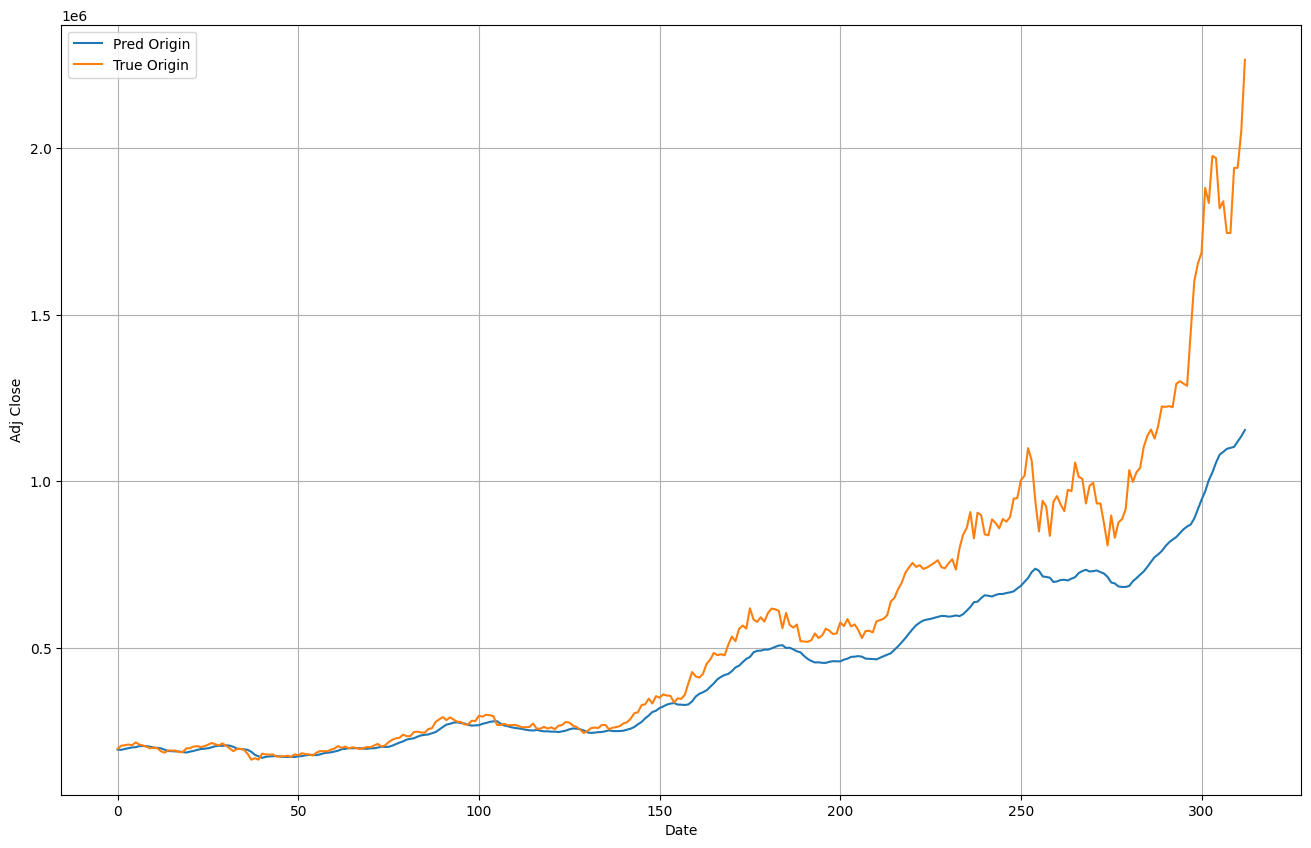

In [203]:
plt.figure(figsize = (16, 10))
plt.plot(pred_origin, label = 'Pred Origin')
plt.plot(true_origin, label = 'True Origin')

plt.legend()
plt.grid()
plt.xlabel('Date')
plt.ylabel('Adj Close')

plt.show()